In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib

# Loading Data and Exploration

In [2]:
df = pd.read_csv("dataset_large__(50_nodes).csv")

In [3]:
df.dtypes
df.describe()
#df.info()
#df.head()

,from_node,to_node,distance_km,time_of_day,traffic_factor,road_type,vehicle_load_pct,weather_condition,travel_time_mins
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,24.984600,25.132400,24.272228,12.548800,1.220412,0.849900,50.439070,0.734800,48.591259
std,14.745491,14.851657,11.530208,3.984621,0.297402,0.783729,28.786475,0.957998,38.790511
min,0.000000,0.000000,0.660000,6.000000,0.700000,0.000000,0.000000,0.000000,1.000000
25%,12.000000,12.000000,15.450000,9.000000,0.970000,0.000000,25.500000,0.000000,21.107500
50%,25.000000,25.000000,23.520000,13.000000,1.110000,1.000000,50.400000,0.000000,37.320000
75%,38.000000,38.000000,32.620000,16.000000,1.520000,1.000000,75.600000,1.000000,64.342500
max,50.000000,50.000000,57.070000,19.000000,1.750000,2.000000,100.000000,3.000000,304.860000


array([[<Axes: title={'center': 'from_node'}>,
        <Axes: title={'center': 'to_node'}>,
        <Axes: title={'center': 'distance_km'}>],
       [<Axes: title={'center': 'time_of_day'}>,
        <Axes: title={'center': 'traffic_factor'}>,
        <Axes: title={'center': 'road_type'}>],
       [<Axes: title={'center': 'vehicle_load_pct'}>,
        <Axes: title={'center': 'weather_condition'}>,
        <Axes: title={'center': 'travel_time_mins'}>]], dtype=object)

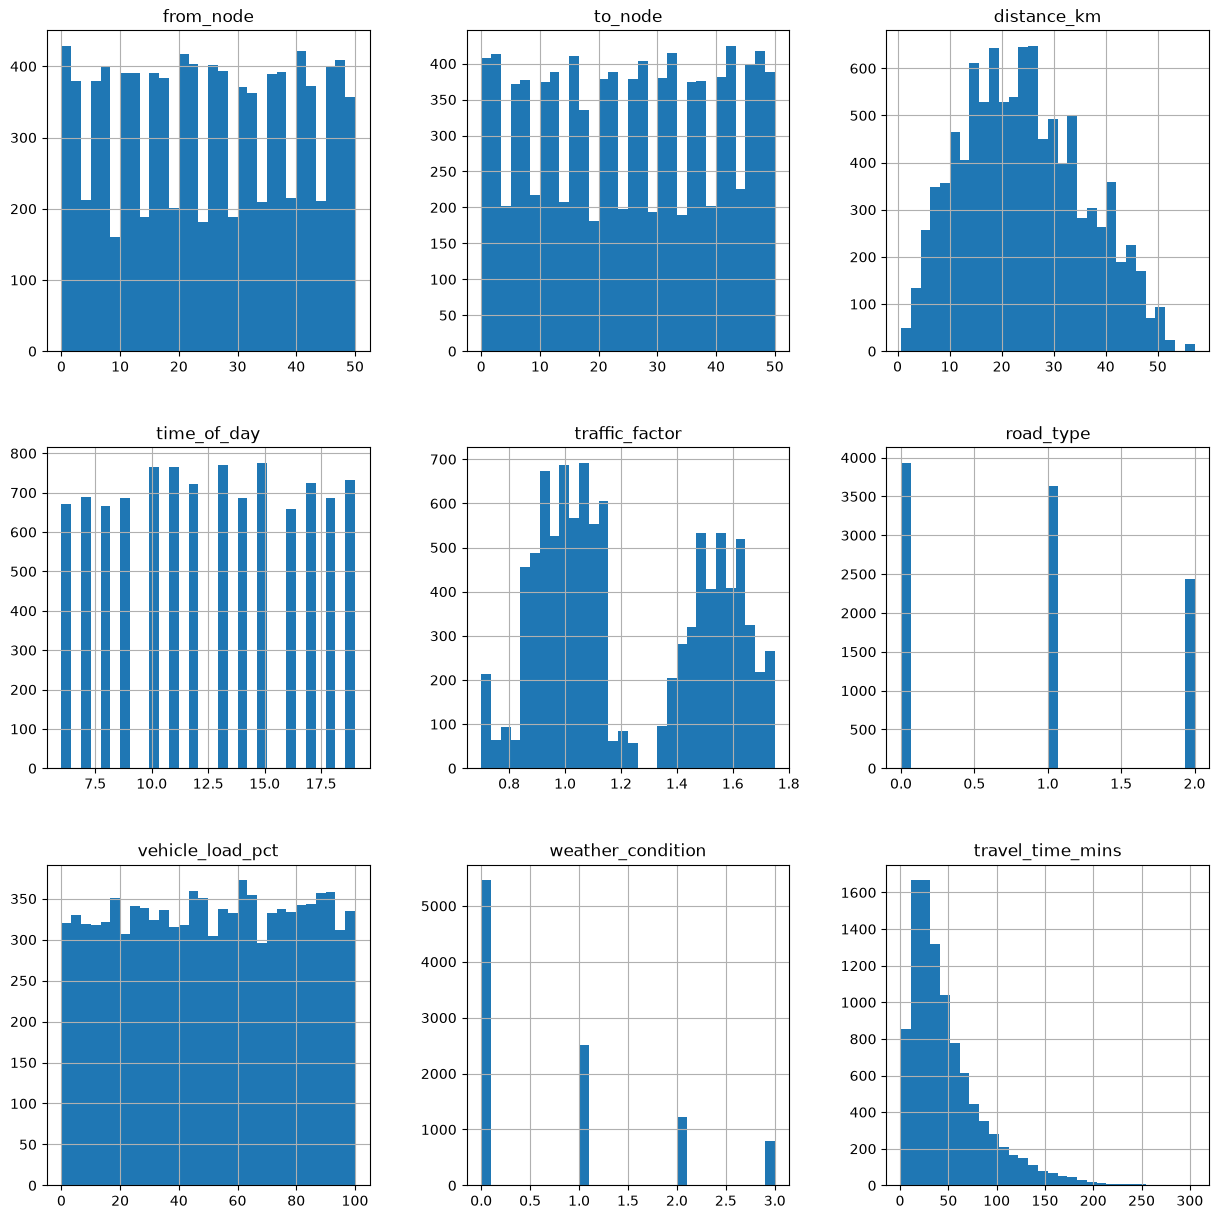

In [4]:
df.hist(bins = 30, figsize = (15,15))

In [5]:
corr_matrix = df.corr().drop('travel_time_mins')
corr_matrix['travel_time_mins'].sort_values(ascending = False).round(3)

distance_km          0.588
traffic_factor       0.276
weather_condition    0.179
vehicle_load_pct     0.039
to_node             -0.009
time_of_day         -0.015
from_node           -0.040
road_type           -0.572
Name: travel_time_mins, dtype: float64

## Preprocessing

In [6]:
X = df.drop('travel_time_mins',axis = 1)
y = df['travel_time_mins']

In [7]:
missing = X.isnull().any().sum()
if missing > 0:
    X = X.fillna(X.median(),inplace = True)
    print(f"Filled with columns median value")
else:
    print(f"No empty cell found")

No empty cell found


# Split Data into Train and Test

In [8]:
X

,from_node,to_node,distance_km,time_of_day,traffic_factor,road_type,vehicle_load_pct,weather_condition
0,40,22,29.21,9,1.41,1,44.1,0
1,13,35,29.65,11,0.90,1,1.6,1
2,44,10,20.85,19,0.70,1,37.4,0
3,34,13,41.44,13,0.87,0,76.2,2
4,33,47,23.61,12,1.08,1,18.9,0
...,...,...,...,...,...,...,...,...
9995,35,3,19.37,10,0.89,1,50.2,2
9996,28,39,34.41,13,0.97,0,62.5,2
9997,11,35,23.64,16,1.72,0,82.2,0
9998,32,26,32.25,18,1.46,1,60.6,0


In [9]:
columns_to_remove = ['from_node','to_node']
X.drop(columns=columns_to_remove, inplace=True)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled,columns = X.columns)

In [11]:
X_scaled 

,distance_km,time_of_day,traffic_factor,road_type,vehicle_load_pct,weather_condition
0,0.428268,-0.890669,0.637512,0.191530,-0.220221,-0.767054
1,0.466431,-0.388714,-1.077423,0.191530,-1.696683,0.276841
2,-0.296820,1.619106,-1.749947,0.191530,-0.452981,-0.767054
3,1.489013,0.113241,-1.178302,-1.084485,0.894942,1.320736
4,-0.057437,-0.137736,-0.472152,0.191530,-1.095676,-0.767054
...,...,...,...,...,...,...
9995,-0.425185,-0.639691,-1.111049,0.191530,-0.008305,1.320736
9996,0.879280,0.113241,-0.842040,-1.084485,0.419000,1.320736
9997,-0.054835,0.866173,1.679924,-1.084485,1.103383,-0.767054
9998,0.691936,1.368128,0.805643,0.191530,0.352993,-0.767054


In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test, y_train,y_test = train_test_split(X_scaled,y,test_size=0.2, random_state = 42)

# Training Model (Simple Linear Regression)

In [13]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 23.3 , 0.36, 10.76,-22.14, 2.06, 6.98]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['distance_km','time_of_day','traffic_factor','road_type', 'vehicle_load_pct','weather_condition']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,48.54
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


##### Testing on some random values.

In [14]:
random_x = X_train.iloc[:5]
random_y = y_train.iloc[:5]
print(f"Predictions:{lin_reg.predict(random_x).round(2)}")
print(f"Actual:     {list(random_y)}")

Predictions:[ 59.03 108.51  67.4   49.04  98.35]
Actual:     [42.25, 110.65, 49.15, 32.59, 85.99]


# Evaluation of the Model

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error

In [16]:
y_pred = lin_reg.predict(X_test)
 
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"\n  MAE  (Mean Absolute Error)       : {mae:.4f} minutes")
print(f"       → predictions off by {mae:.2f} mins on average")
print(f"\n  RMSE (Root Mean Squared Error)   : {rmse:.4f} minutes")
print(f"       → large errors penalised, {rmse:.2f} mins spread")
print(f"\n  R²   (Coefficient of Determination): {r2:.4f}")


  MAE  (Mean Absolute Error)       : 12.6413 minutes
       → predictions off by 12.64 mins on average

  RMSE (Root Mean Squared Error)   : 17.2824 minutes
       → large errors penalised, 17.28 mins spread

  R²   (Coefficient of Determination): 0.8005


## Cross Validation

In [17]:
# Cross-validation score (more robust evaluation)
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lin_reg, X_train, y_train,cv=4, scoring="r2")

print(f"\n  4-Fold Cross-Validation R²:")
print(f"    Scores : {[round(s, 4) for s in cv_scores]}")
print(f"    Mean   : {cv_scores.mean():.4f}")
print(f"    Std    : {cv_scores.std():.4f}")


  4-Fold Cross-Validation R²:
    Scores : [np.float64(0.7891), np.float64(0.7794), np.float64(0.7963), np.float64(0.794)]
    Mean   : 0.7897
    Std    : 0.0065



------------------------------------------------------------
STEP 7: Visualising Results
------------------------------------------------------------
  Saved: linear_regression_evaluation.png


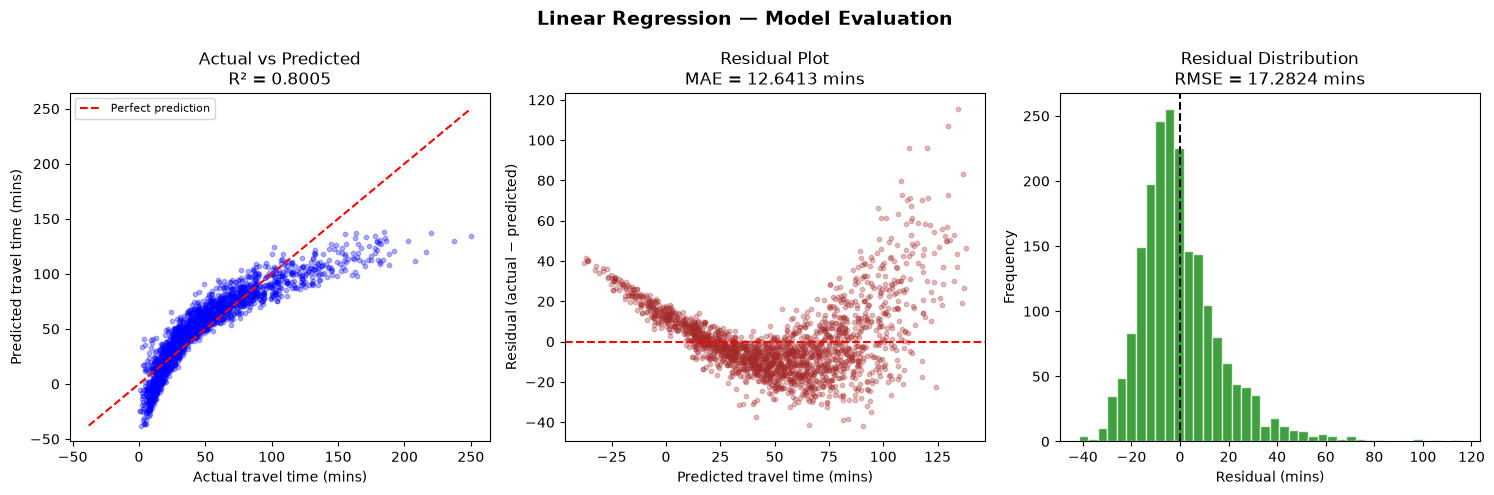

In [18]:
print("\n" + "-"*60)
print("STEP 7: Visualising Results")
print("-"*60)
 
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Linear Regression — Model Evaluation", fontsize=14, fontweight="bold")
 
# Plot 1: Actual vs Predicted
ax[0].scatter(y_test, y_pred, alpha=0.3, s=10, color="blue")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=1.5, label="Perfect prediction")
ax[0].set_xlabel("Actual travel time (mins)")
ax[0].set_ylabel("Predicted travel time (mins)")
ax[0].set_title(f"Actual vs Predicted\nR² = {r2:.4f}")
ax[0].legend(fontsize=8)
 
# Plot 2: Residuals (errors)
residuals = y_test - y_pred
ax[1].scatter(y_pred, residuals, alpha=0.3, s=10, color="brown")
ax[1].axhline(0, color="red", linestyle="--", lw=1.5)
ax[1].set_xlabel("Predicted travel time (mins)")
ax[1].set_ylabel("Residual (actual − predicted)")
ax[1].set_title(f"Residual Plot\nMAE = {mae:.4f} mins")
 
# Plot 3: Residual distribution
ax[2].hist(residuals, bins=40, color="green", alpha=0.75, edgecolor="white")
ax[2].axvline(0, color="black", linestyle="--", lw=1.5)
ax[2].set_xlabel("Residual (mins)")
ax[2].set_ylabel("Frequency")
ax[2].set_title(f"Residual Distribution\nRMSE = {rmse:.4f} mins")
 
plt.tight_layout()
plt.savefig("linear_regression_evaluation.png", dpi=150, bbox_inches="tight")
print("  Saved: linear_regression_evaluation.png")
plt.show()


In [19]:
# ============================================================
# STEP 9 — SAVE THE MODEL
# ============================================================

print("\n" + "-"*60)
print("STEP 9: Saving Model")
print("-"*60)

joblib.dump(lin_reg, "linear_model_50.pkl")
joblib.dump(scaler, "linear_model_50_scaler.pkl")

print("  Saved: linear_model_50.pkl")
print("  Saved: linear_model_50_scaler.pkl")


------------------------------------------------------------
STEP 9: Saving Model
------------------------------------------------------------
  Saved: linear_model_50.pkl
  Saved: linear_model_50_scaler.pkl
